In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load dataset
csv_path = r'C:\Users\User\Desktop\ML Assignment\ML-Assignment\data\deliveries.csv'
df_deliveries = pd.read_csv(csv_path)

print("Dataset Loaded!")
df_deliveries.head()

Dataset Loaded!


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [102]:
# Grouping data: Powerplay runs (first 6 overs) vs Total runs
pp_runs = df_deliveries[df_deliveries['over'] <= 6].groupby(['match_id', 'inning'])['total_runs'].sum().reset_index()
total_runs = df_deliveries.groupby(['match_id', 'inning'])['total_runs'].sum().reset_index()

# Merging to create final dataset
df = pd.merge(pp_runs, total_runs, on=['match_id', 'inning'], suffixes=('_6_overs', '_total'))

print("Preprocessing Done. Shape of data:", df.shape)
df.head()

Preprocessing Done. Shape of data: (1284, 4)


,match_id,inning,total_runs_6_overs,total_runs_total
0,1,1,59,207
1,1,2,54,172
2,2,1,61,184
3,2,2,59,187
4,3,1,52,183


In [103]:
X = df[['total_runs_6_overs', 'inning']]
y = df['total_runs_total']

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [105]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [106]:
y_pred = model.predict(X_test)

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 21.864586889639273
MSE: 817.5445852804827
R2 Score: 0.2305661562150041


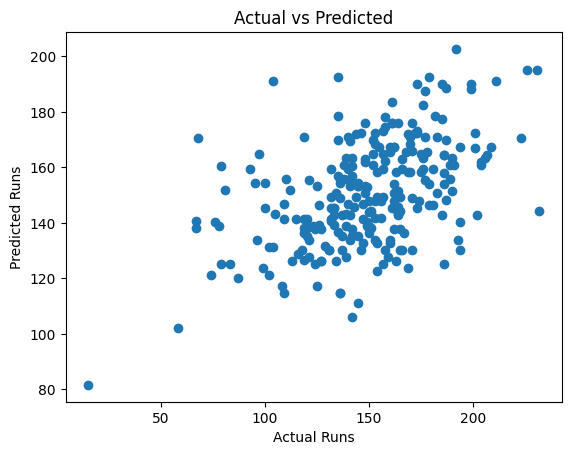

In [108]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")
plt.title("Actual vs Predicted")
plt.show()

In [109]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: 128.2159598740957
Coefficient: [  1.268197  -21.8862024]


In [110]:
from sklearn.metrics import r2_score

# 🔹 Train predictions
y_train_pred = model.predict(X_train)

# 🔹 Test predictions (oya already thiyenawa)
y_test_pred = model.predict(X_test)

# 🔹 Train R2
train_r2 = r2_score(y_train, y_train_pred)

# 🔹 Test R2
test_r2 = r2_score(y_test, y_test_pred)

print("Train R2 Score:", train_r2)
print("Test R2 Score:", test_r2)

Train R2 Score: 0.3487781129316784
Test R2 Score: 0.2305661562150041
